# 1 
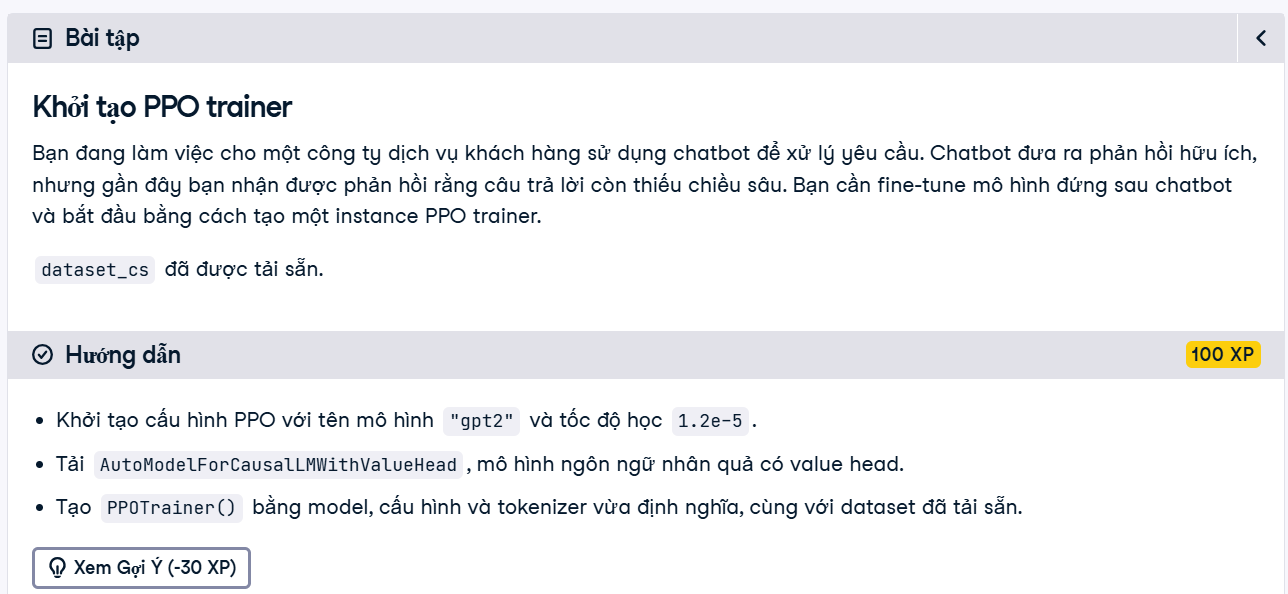

In [ ]:
from trl import PPOConfig, AutoModelForCausalLMWithValueHead, PPOTrainer
from transformers import AutoTokenizer

# Initialize PPO Configuration
gpt2_config = ____(model_name=____, learning_rate=____)

# Load the model
gpt2_model = ____(gpt2_config.model_name)
gpt2_tokenizer = AutoTokenizer.from_pretrained(gpt2_config.model_name)

# Initialize PPO Trainer
ppo_trainer = ____

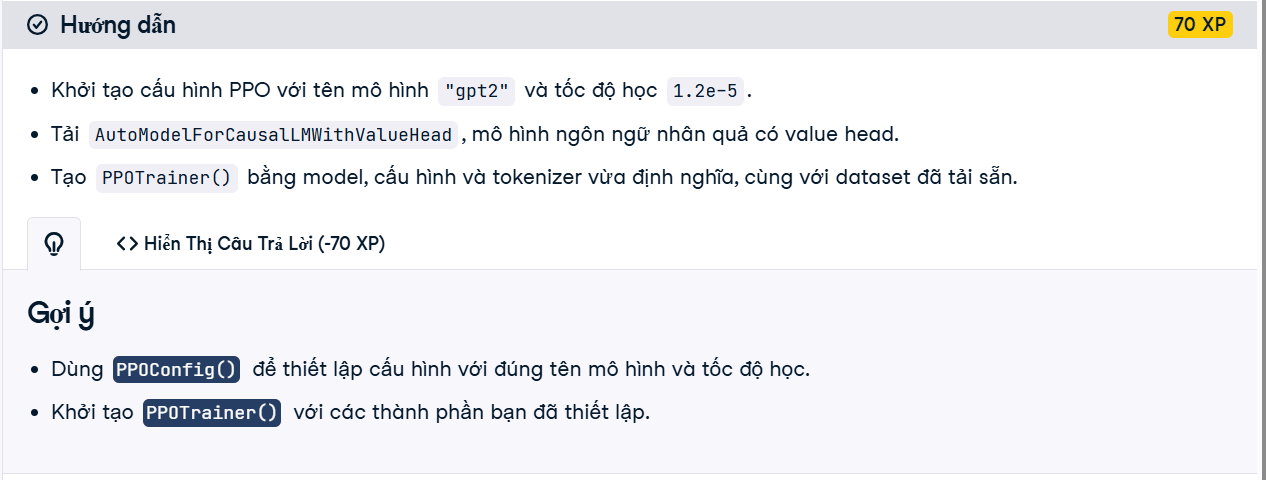

In [ ]:
"""
from trl import PPOConfig, AutoModelForCausalLMWithValueHead, PPOTrainer
from transformers import AutoTokenizer

# Initialize PPO Configuration
gpt2_config = PPOConfig(model_name="gpt2", learning_rate=1.2e-5)

# Load the model
gpt2_model = AutoModelForCausalLMWithValueHead.from_pretrained(gpt2_config.model_name)
gpt2_tokenizer = AutoTokenizer.from_pretrained(gpt2_config.model_name)

# Initialize PPO Trainer
ppo_trainer = PPOTrainer(model=gpt2_model, config=gpt2_config, dataset=dataset_cs, tokenizer=gpt2_tokenizer)
"""

# 2
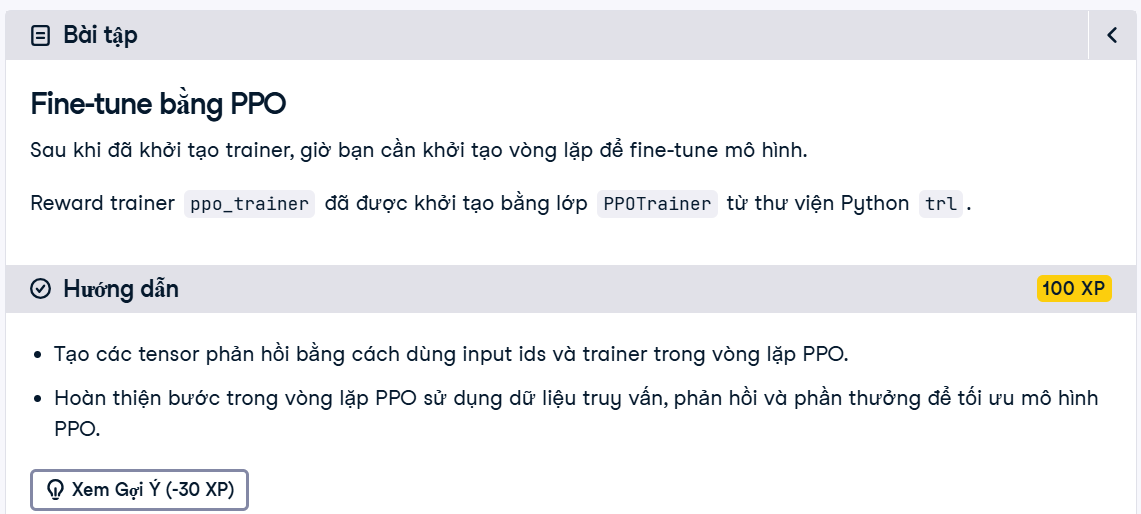

In [ ]:
for batch in tqdm(ppo_trainer.dataloader): 

    # Generate responses for the given queries using the trainer
    response_tensors = ____(batch["input_ids"])

    batch["response"] = [tokenizer.decode(r.squeeze()) for r in response_tensors]

    texts = [q + r for q, r in zip(batch["query"], batch["response"])]

    rewards = reward_model(texts)

    # Training PPO step with the query, responses ids, and rewards
    stats = ____(batch["input_ids"], response_tensors, rewards)

    ppo_trainer.log_stats(stats, batch, rewards)

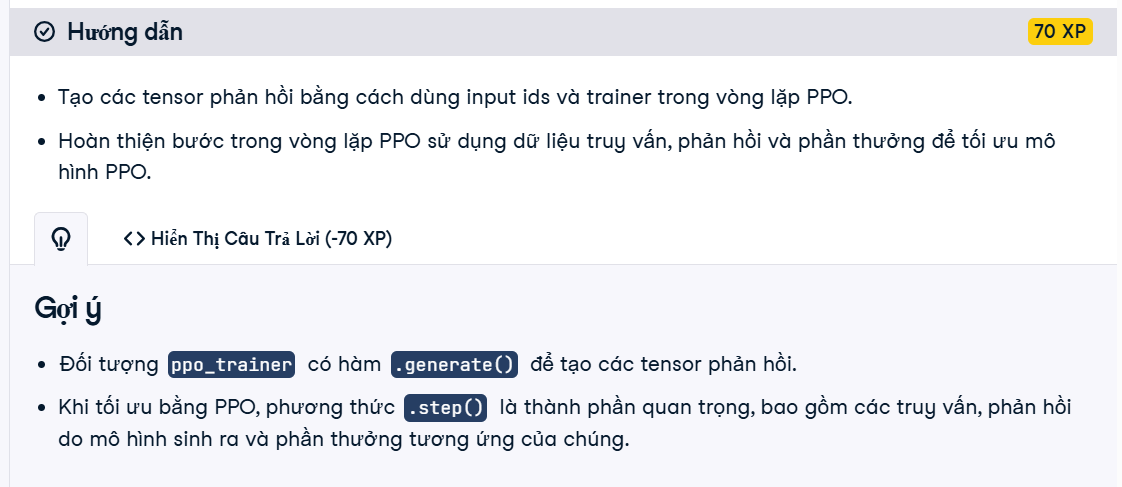

In [ ]:
"""
for batch in tqdm(ppo_trainer.dataloader): 

    # Generate responses for the given queries using the trainer
    response_tensors = ppo_trainer.generate(batch["input_ids"])

    batch["response"] = [tokenizer.decode(r.squeeze()) for r in response_tensors]

    texts = [q + r for q, r in zip(batch["query"], batch["response"])]

    rewards = reward_model(texts)

    # Training PPO step with the query, responses ids, and rewards
    stats = ppo_trainer.step(batch["input_ids"], response_tensors, rewards)

    ppo_trainer.log_stats(stats, batch, rewards)
    
    """